## Learning Curve — MIL Gated Attention
### Stratégie : jeux équilibrés croissants (10R+10S → 15R+15S → ... → 53R+53S)
Objectif : montrer qu'on obtient un modèle performant avec un **minimum de données**.

In [21]:
import os, glob, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
#from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              precision_recall_curve, roc_curve)

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [22]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

import sys
print(f"Python : {sys.version}")
print(f"Torch  : {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
#if torch.cuda.is_available():
    #print(f"GPU    : {torch.cuda.get_device_name()}")

Python : 3.12.12 | packaged by conda-forge | (main, Oct 13 2025, 14:34:15) [GCC 14.3.0]
Torch  : 2.6.0
CUDA   : True


In [23]:
# Configuration de hyperparamètres

PT_DIR      = "/shared/projects/pangaimix/dataset_61R_61S/embeddings"
LABELS_PATH = "matrice_listantibio_final.cleaned.list"

SEED       = 42
BATCH_SIZE = 8
EPOCHS     = 1000
LR         = 0.0005
ATTN_DIM   = 64
HIDDEN     = 128
DROPOUT    = 0.15

# Paliers : nombre de génomes PAR CLASSE (S et R)
SIZES     = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45] # 50, 55, 60 : à elever parce que ils vont etre identique au plier 45 !
#N_REPEATS = 4   # répétitions par palier pour stabiliser les résultats

device = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f" Config | device : {device}")
print(f"   Paliers (par classe) : {SIZES}")
print(f"   Soit en total génomes : {[2*s for s in SIZES]}")
#print(f"   Répétitions par palier : {N_REPEATS}")

 Config | device : cuda
   Paliers (par classe) : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45]
   Soit en total génomes : [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 30, 40, 50, 60, 70, 80, 90]


In [24]:
# Chargement des embeddings et labels

def load_pt(fp):
    obj = torch.load(fp, map_location="cpu")
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X   = obj["last_hidden_state"]
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)
    if X.ndim == 3:
        X = X.squeeze(0)
    return gid, X.float()

def load_labels(path):
    df = pd.read_csv(path, sep="\t", dtype=str)
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"].astype(int)))

id_to_y = load_labels(LABELS_PATH)

all_files = sorted(glob.glob(os.path.join(PT_DIR, "*.pt")))
matched   = [fp for fp in all_files if load_pt(fp)[0] in id_to_y]

all_labels      = np.array([id_to_y[load_pt(fp)[0]] for fp in matched])
resistant_idx   = np.where(all_labels == 1)[0]   # indices dans matched[]
susceptible_idx = np.where(all_labels == 0)[0]

n_R = len(resistant_idx)
n_S = len(susceptible_idx)

_, X0   = load_pt(matched[0])
emb_dim = X0.shape[1]

print(f" Dataset complet :")
print(f"   Total labellisés : {len(matched)}")
print(f"   Résistants  (R)  : {n_R}  ({n_R/len(matched):.1%})")
print(f"   Sensibles   (S)  : {n_S}  ({n_S/len(matched):.1%})")
print(f"   Embedding dim    : {emb_dim}")
print(f"   Palier max       : {min(n_R, n_S)} par classe")

 Dataset complet :
   Total labellisés : 122
   Résistants  (R)  : 61  (50.0%)
   Sensibles   (S)  : 61  (50.0%)
   Embedding dim    : 480
   Palier max       : 61 par classe


In [25]:
# Définition de Dataset MIL & collate

class GenomeMILDataset(Dataset):
    def __init__(self, file_list, id_to_y):
        self.files   = file_list
        self.id_to_y = id_to_y

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        gid, X = load_pt(self.files[idx])
        y = float(self.id_to_y[gid])
        return X, torch.tensor(y, dtype=torch.float32), gid
    
    
def mil_collate(batch):
    xs, ys, gids = zip(*batch)
    D    = xs[0].shape[1]
    Pmax = max(x.shape[0] for x in xs)
    Xpad = torch.zeros((len(xs), Pmax, D))
    mask = torch.zeros((len(xs), Pmax))
    for i, x in enumerate(xs):
        Xpad[i, :x.shape[0]] = x
        mask[i, :x.shape[0]] = 1.0
    return Xpad, mask, torch.stack(list(ys)), list(gids)

In [26]:
# Modèle MIL Gated Attention

class GatedAttentionMIL(nn.Module):
    def __init__(self, emb_dim, attn_dim=64, hidden=128, dropout=0.15):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        self.V = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Tanh())
        self.U = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Sigmoid())
        self.w = nn.Linear(attn_dim, 1)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            #nn.BatchNorm1d(hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, X, mask):
        X = self.drop(X)
        A = self.w(self.V(X) * self.U(X)).squeeze(-1)
        A = A.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(A, dim=1)
        z     = torch.sum(X * alpha.unsqueeze(-1), dim=1)
        logit = self.classifier(z).squeeze(-1)
        return logit, alpha


@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    all_y, all_prob = [], []
    for Xpad, mask, y, _ in loader:
        logits, _ = model(Xpad.to(device), mask.to(device))
        all_prob.append(torch.sigmoid(logits).cpu().numpy())
        all_y.append(y.numpy())
    return np.concatenate(all_y), np.concatenate(all_prob)


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1":  f1_score(y_true, y_pred, zero_division=0),
        "auc": auc,
    }

n_params = sum(p.numel() for p in
               GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).parameters()
               if p.requires_grad)
print(f" Modèle prêt | emb_dim={emb_dim} | paramètres={n_params:,}")

 Modèle prêt | emb_dim=480 | paramètres=123,586


In [27]:
# Incremental_training (4 folds)

from sklearn.model_selection import StratifiedKFold

set_seed(SEED)
N_FOLDS    = 4
N_TEST_EXT = 15   # R par fold (sauf un fold qui aura 16R)

# Division des 61R en 4 groupes fixes
all_R = resistant_idx.copy()
np.random.shuffle(all_R)

# Groupes de test fixes
fold_test_R = np.array_split(all_R, N_FOLDS)

# ex :
        # fold_test_R[0] = Groupe A (16R)
        # fold_test_R[1] = Groupe B (15R)
        # fold_test_R[2] = Groupe C (15R)
        # fold_test_R[3] = Groupe D (15R)

all_S = susceptible_idx.copy()
np.random.shuffle(all_S)
fold_test_S = np.array_split(all_S, N_FOLDS)

print(f"61R divisés en {N_FOLDS} groupes de test fixes :")
for k, grp in enumerate(fold_test_R):
    print(f"   Groupe {k+1} : {len(grp)}R")
print()

# ex :
        # fold_test_s[0] = Groupe A (16R)
        # fold_test_s[1] = Groupe B (15R)
        # fold_test_s[2] = Groupe C (15R)
        # fold_test_s[3] = Groupe D (15R)

lc_results  = []
best_models = {}   # n_per_class : meilleur state_dict (meilleur fold)
all_fold_models = {}

print(f"{'Palier':>14} | {'AUC moy':>8} {'±':>5} | {'F1 moy':>8} {'±':>5} | "
      f"{'AUC f1':>6} {'AUC f2':>6} {'AUC f3':>6} {'AUC f4':>6}")
print("-" * 80)

for n_per_class in SIZES:

    fold_aucs, fold_f1s = [], []
    fold_sens, fold_spec = [], []
    fold_TP, fold_TN      = [], [] 
    fold_FP, fold_FN      = [], []
    best_auc_palier     = -1.0
    best_state_palier   = None

    for fold_idx in range(N_FOLDS):

        seed_run = SEED + fold_idx * 100 + n_per_class
        set_seed(seed_run)

        # Test : groupe fixe du fold
        te_R = fold_test_R[fold_idx]
        te_S = fold_test_S[fold_idx][:len(te_R)]   # prend len(te_R) S du groupe fixe
        te_files = [matched[i] for i in np.concatenate([te_R, te_S])]

        # Train : R disponibles = tous les R hors test
        pool_R_fold = np.concatenate([
            fold_test_R[k] for k in range(N_FOLDS) if k != fold_idx])
        
        # pool_R_fold = les R des 3 autres groupes
        # ex : fold 1 → pool = Groupe B+C+D = 40R
        
        # Pool S — tous les S des 3 autres groupes
        pool_S_fold = np.concatenate([
            fold_test_S[k] for k in range(N_FOLDS) if k != fold_idx])

        # On pioche n_per_class R parmi le pool disponible
        n_train_R = min(n_per_class, len(pool_R_fold))
        sel_R = np.random.choice(pool_R_fold, size=n_train_R, replace=False)
        sel_S = np.random.choice(pool_S_fold, size=n_train_R, replace=False)

        tr_files  = [matched[i] for i in np.concatenate([sel_R, sel_S])]
        tr_labels = np.array([id_to_y[load_pt(f)[0]] for f in tr_files])
        
        # DataLoaders
        tr_ds = GenomeMILDataset(tr_files, id_to_y)
        te_ds = GenomeMILDataset(te_files, id_to_y)

        bs = max(2, min(BATCH_SIZE, n_train_R // 2))

        tr_loader = DataLoader(tr_ds, batch_size=bs, shuffle=True, collate_fn=mil_collate)
        te_loader = DataLoader(te_ds, batch_size=bs, shuffle=False, collate_fn=mil_collate)

        # Entraînement avec plateau stopping
        model     = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

        best_loss  = float("inf")
        no_improve = 0
        PATIENCE   = 30

        for epoch in range(1, EPOCHS + 1):
            model.train()
            epoch_loss, n_batches = 0.0, 0
            for Xpad, mask, y, _ in tr_loader:
                Xpad, mask, y = Xpad.to(device), mask.to(device), y.to(device)
                optimizer.zero_grad()
                logits, _ = model(Xpad, mask)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
                n_batches  += 1

            train_loss = epoch_loss / n_batches
            if train_loss < best_loss - 1e-4:
                best_loss  = train_loss
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= PATIENCE:
                    break
                
        # Évaluation
        test_y, test_prob = get_probs(model, te_loader)
        
        m = compute_metrics(test_y, test_prob, threshold=0.5)
        
        auc_fold = m["auc"] or 0.0
        f1_fold  = m["f1"]
        
        # Sensibilité et Spécificité
        y_pred = (test_prob >= 0.5).astype(int)
        TP = int(((y_pred == 1) & (test_y == 1)).sum())
        TN = int(((y_pred == 0) & (test_y == 0)).sum())
        FP = int(((y_pred == 1) & (test_y == 0)).sum())
        FN = int(((y_pred == 0) & (test_y == 1)).sum())

        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # recall R
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0  # recall S

        fold_aucs.append(auc_fold)
        fold_f1s.append(f1_fold)
        fold_sens.append(sensitivity)
        fold_spec.append(specificity)
        
        fold_TP.append(TP)
        fold_TN.append(TN)  
        fold_FP.append(FP)  
        fold_FN.append(FN) 
                
        if n_per_class not in all_fold_models:
            all_fold_models[n_per_class] = {}
        all_fold_models[n_per_class][fold_idx] = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        # Garde le meilleur modèle en mémoire 
        if auc_fold > best_auc_palier:
            best_auc_palier   = auc_fold
            best_state_palier = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    # Stocke le meilleur modèle du palier
    best_models[n_per_class] = best_state_palier
    best_fold = int(np.argmax(fold_aucs)) + 1

    lc_results.append({
        "n_per_class": n_per_class,
        "n_total":     2 * n_per_class,
        "auc_mean":    np.mean(fold_aucs),
        "auc_std":     np.std(fold_aucs),
        "f1_mean":     np.mean(fold_f1s),
        "f1_std":      np.std(fold_f1s),
        "sens_mean":   np.mean(fold_sens),
        "sens_std":    np.std(fold_sens),   
        "spec_mean":   np.mean(fold_spec),  
        "spec_std":    np.std(fold_spec),
        "fold_aucs":   fold_aucs,
        "fold_f1s":    fold_f1s,
        "fold_sens":   fold_sens,           
        "fold_spec":   fold_spec,            
        "best_fold":   best_fold,
        "fold_TP":     fold_TP,   
        "fold_TN":     fold_TN,   
        "fold_FP":     fold_FP,   
        "fold_FN":     fold_FN, 
    })

    print(
        f"  {n_per_class:3d}R+{n_per_class:3d}S = {2*n_per_class:3d} | "
        f"{np.mean(fold_aucs):8.3f} {np.std(fold_aucs):5.3f} | "
        f"{np.mean(fold_f1s):8.3f} {np.std(fold_f1s):5.3f} | "
        f"{fold_aucs[0]:6.3f} {fold_aucs[1]:6.3f} "
        f"{fold_aucs[2]:6.3f} {fold_aucs[3]:6.3f} "
        f"(best=fold{best_fold})"
    )


print("\n Learning Curve terminée !")
print(f"   Modèles en mémoire : best_models[n] pour n dans {list(best_models.keys())}")

61R divisés en 4 groupes de test fixes :
   Groupe 1 : 16R
   Groupe 2 : 15R
   Groupe 3 : 15R
   Groupe 4 : 15R

        Palier |  AUC moy     ± |   F1 moy     ± | AUC f1 AUC f2 AUC f3 AUC f4
--------------------------------------------------------------------------------
    1R+  1S =   2 |    0.739 0.113 |    0.601 0.145 |  0.656  0.773  0.618  0.907 (best=fold4)
    2R+  2S =   4 |    0.772 0.114 |    0.744 0.060 |  0.887  0.582  0.796  0.822 (best=fold1)
    3R+  3S =   6 |    0.713 0.051 |    0.526 0.307 |  0.660  0.689  0.796  0.707 (best=fold3)
    4R+  4S =   8 |    0.644 0.081 |    0.637 0.058 |  0.699  0.662  0.707  0.507 (best=fold3)
    5R+  5S =  10 |    0.779 0.117 |    0.639 0.168 |  0.707  0.631  0.844  0.933 (best=fold4)
    6R+  6S =  12 |    0.688 0.057 |    0.663 0.031 |  0.641  0.764  0.720  0.627 (best=fold2)
    7R+  7S =  14 |    0.834 0.070 |    0.735 0.050 |  0.816  0.756  0.818  0.947 (best=fold4)
    8R+  8S =  16 |    0.718 0.159 |    0.674 0.093 |  0.895 

In [28]:
# Résumé tableau 

df_lc = pd.DataFrame([{
    "n_par_classe": r["n_per_class"],
    "n_total":      r["n_total"],
    "AUC_mean":     round(r["auc_mean"],   3),
    #"AUC_std":      round(r["auc_std"],    3),
    "F1_mean":      round(r["f1_mean"],    3),
    #"F1_std":       round(r["f1_std"],     3),
    "Sens_mean":    round(r["sens_mean"],  3),
    #"Sens_std":     round(r["sens_std"],   3),
    "Spec_mean":    round(r["spec_mean"],  3),
    #"Spec_std":     round(r["spec_std"],   3),
    "best_fold":    r["best_fold"],
} for r in lc_results])

print("                Résumé Learning Curve")
print("=" * 90)
print(df_lc.to_string(index=False))
print("=" * 90)

# Meilleurs paliers
best_auc_idx  = int(df_lc["AUC_mean"].argmax())
best_sens_idx = int(df_lc["Sens_mean"].argmax())
best_spec_idx = int(df_lc["Spec_mean"].argmax())

print(f"\n  Meilleure AUC         : {df_lc.iloc[best_auc_idx]['AUC_mean']} "
      f"→ palier {df_lc.iloc[best_auc_idx]['n_total']} génomes")
print(f"  Meilleure Sensibilité : {df_lc.iloc[best_sens_idx]['Sens_mean']} "
      f"→ palier {df_lc.iloc[best_sens_idx]['n_total']} génomes")
print(f"  Meilleure Spécificité : {df_lc.iloc[best_spec_idx]['Spec_mean']} "
      f"→ palier {df_lc.iloc[best_spec_idx]['n_total']} génomes")

                Résumé Learning Curve
 n_par_classe  n_total  AUC_mean  F1_mean  Sens_mean  Spec_mean  best_fold
            1        2     0.739    0.601      0.494      0.870          4
            2        4     0.772    0.744      0.804      0.636          1
            3        6     0.713    0.526      0.517      0.783          3
            4        8     0.644    0.637      0.757      0.407          3
            5       10     0.779    0.639      0.629      0.735          4
            6       12     0.688    0.663      0.606      0.772          2
            7       14     0.834    0.735      0.740      0.735          4
            8       16     0.718    0.674      0.689      0.652          1
            9       18     0.815    0.753      0.702      0.839          3
           10       20     0.704    0.658      0.728      0.574          4
           15       30     0.797    0.753      0.822      0.654          4
           20       40     0.789    0.701      0.690      0.72

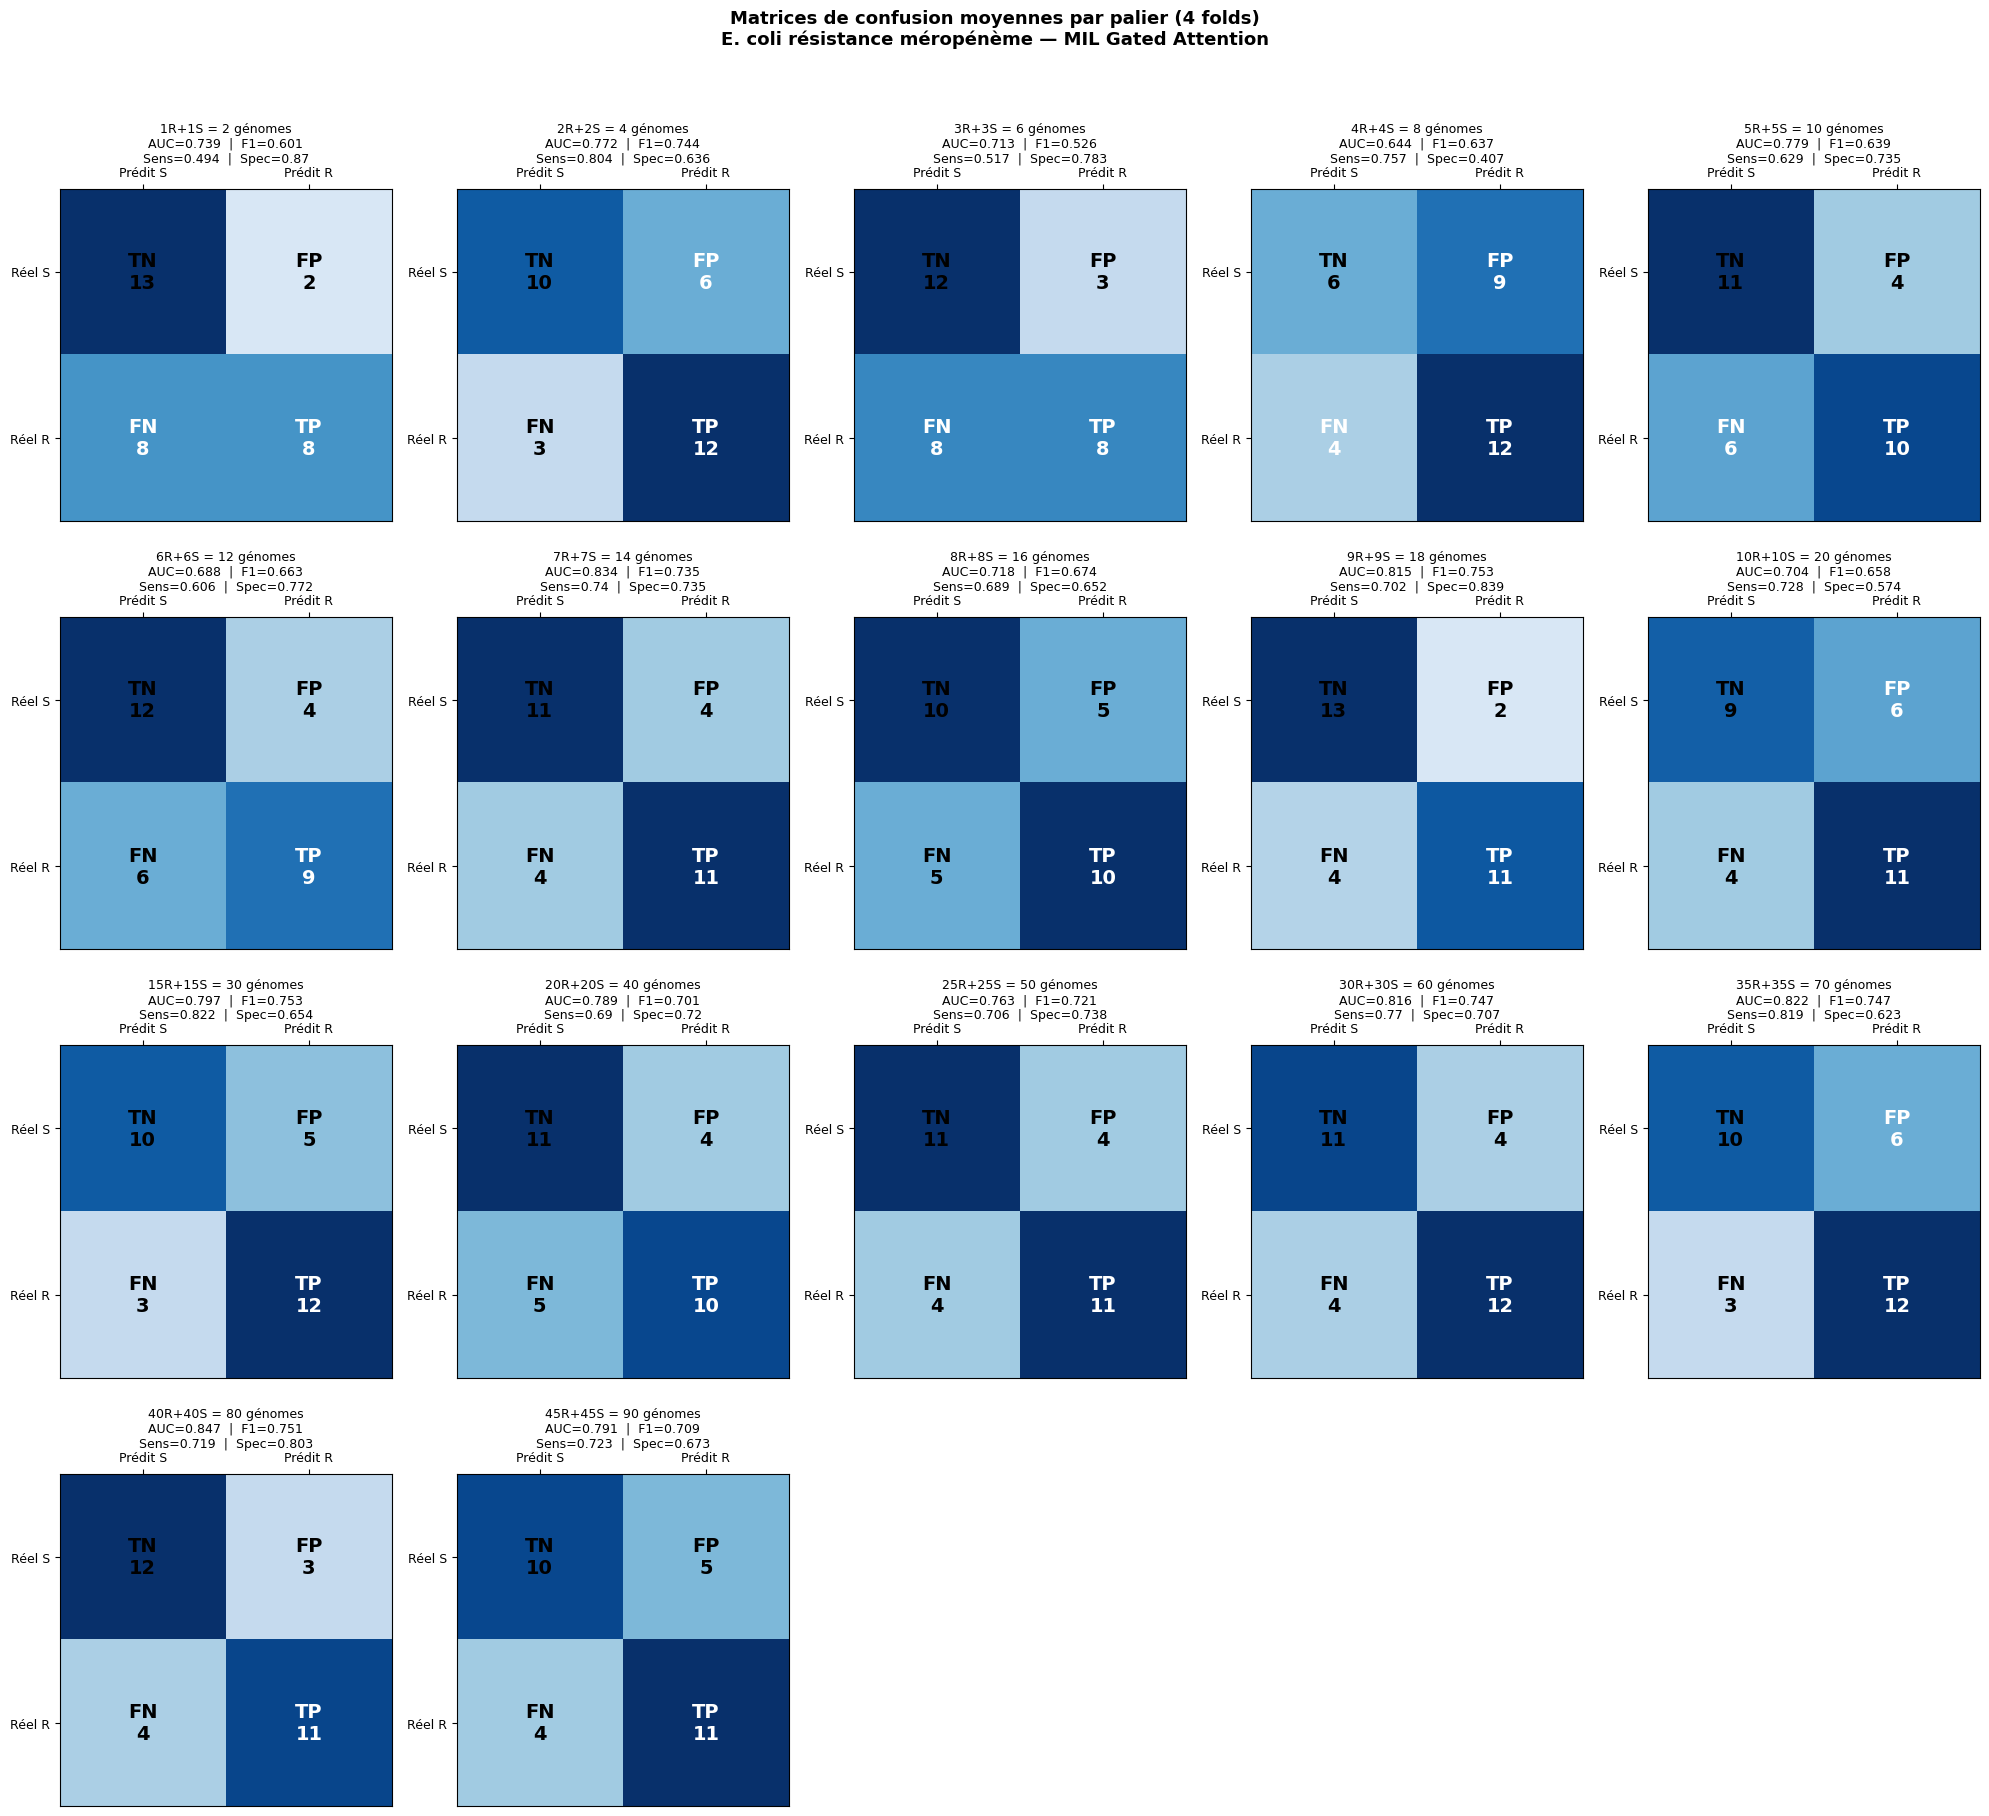

Figure sauvegardée → confusion_matrices_MIL.png


In [29]:
# Matrices de confusion par palier

from sklearn.metrics import confusion_matrix
import matplotlib.patches as mpatches

n_paliers = len(lc_results)
n_cols    = 5
n_rows    = (n_paliers + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 4, n_rows * 4.5))
axes = axes.flatten()

for ax_idx, r in enumerate(lc_results):
    ax = axes[ax_idx]

    # Moyenne des TP/TN/FP/FN sur les 4 folds
    TP = round(np.mean(r["fold_TP"]))
    TN = round(np.mean(r["fold_TN"]))
    FP = round(np.mean(r["fold_FP"]))
    FN = round(np.mean(r["fold_FN"]))

    cm = np.array([[TN, FP],
                   [FN, TP]])

    # Affichage matrice
    im = ax.imshow(cm, cmap="Blues", vmin=0)

    # Valeurs dans les cases
    ax.text(0, 0, f"TN\n{TN}", ha="center", va="center",
            fontsize=14, fontweight="bold", color="black")
    ax.text(1, 0, f"FP\n{FP}", ha="center", va="center",
            fontsize=14, fontweight="bold", color="white" if FP > TN/2 else "black")
    ax.text(0, 1, f"FN\n{FN}", ha="center", va="center",
            fontsize=14, fontweight="bold", color="white" if FN > TN/2 else "black")
    ax.text(1, 1, f"TP\n{TP}", ha="center", va="center",
            fontsize=14, fontweight="bold", color="white")

    # Axes
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Prédit S", "Prédit R"], fontsize=9)
    ax.set_yticklabels(["Réel S", "Réel R"], fontsize=9)
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()

    # Titre + métriques
    sens = round(r["sens_mean"], 3)
    spec = round(r["spec_mean"], 3)
    ax.set_title(
        f"{r['n_per_class']}R+{r['n_per_class']}S = {r['n_total']} génomes\n"
        f"AUC={round(r['auc_mean'],3)}  |  F1={round(r['f1_mean'],3)}\n"
        f"Sens={sens}  |  Spec={spec}",
        fontsize=9, pad=3
    )

# Masquer les axes vides
for ax_idx in range(len(lc_results), len(axes)):
    axes[ax_idx].set_visible(False)

fig.suptitle(
    "Matrices de confusion moyennes par palier (4 folds)\n"
    "E. coli résistance méropénème — MIL Gated Attention",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("confusion_matrices_MIL.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée → confusion_matrices_MIL.png")

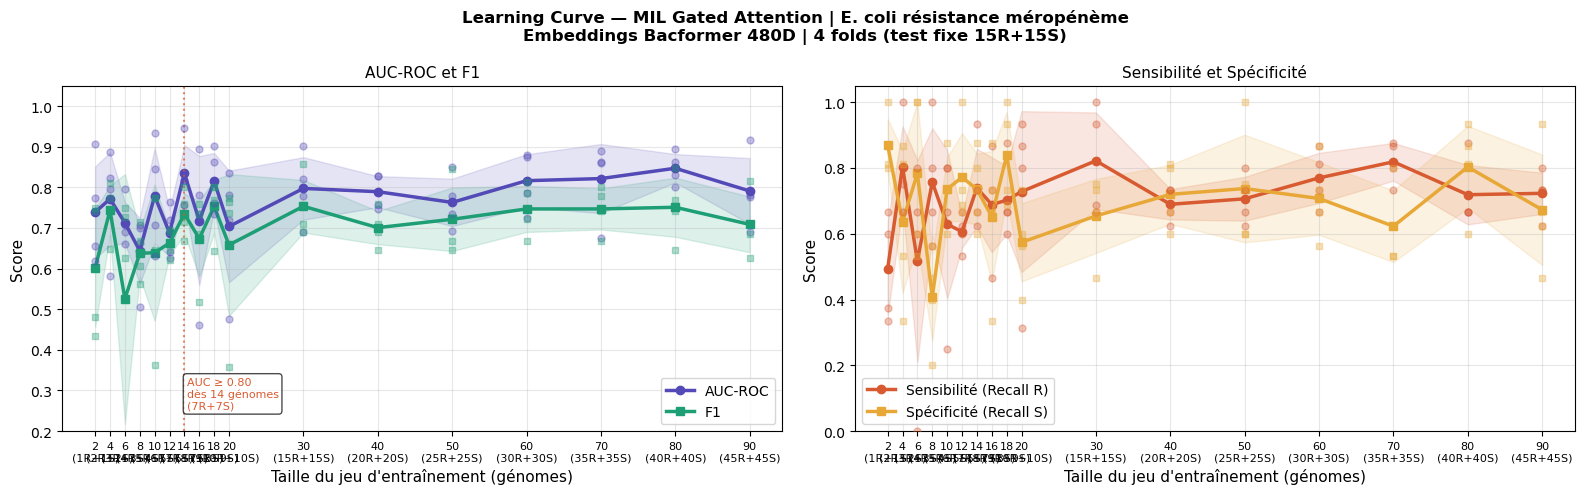

In [30]:
# Visualisation — AUC + F1 + Sens + Spec

sizes_plot = [r["n_total"]   for r in lc_results]
auc_means  = [r["auc_mean"]  for r in lc_results]
auc_stds   = [r["auc_std"]   for r in lc_results]
f1_means   = [r["f1_mean"]   for r in lc_results]
f1_stds    = [r["f1_std"]    for r in lc_results]
sens_means = [r["sens_mean"] for r in lc_results]
sens_stds  = [r["sens_std"]  for r in lc_results]
spec_means = [r["spec_mean"] for r in lc_results]
spec_stds  = [r["spec_std"]  for r in lc_results]

COLOR_AUC  = "#534AB7"
COLOR_F1   = "#1D9E75"
COLOR_SENS = "#D85A30"
COLOR_SPEC = "#E8A838"

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    "Learning Curve — MIL Gated Attention | E. coli résistance méropénème\n"
    "Embeddings Bacformer 480D | 4 folds (test fixe 15R+15S)",
    fontsize=12, fontweight="bold"
)

# Graphe 1 : AUC + F1 
ax = axes[0]

ax.plot(sizes_plot, auc_means, marker="o", linewidth=2.5,
        color=COLOR_AUC, label="AUC-ROC")
ax.fill_between(sizes_plot,
                np.array(auc_means) - np.array(auc_stds),
                np.array(auc_means) + np.array(auc_stds),
                alpha=0.15, color=COLOR_AUC)

ax.plot(sizes_plot, f1_means, marker="s", linewidth=2.5,
        color=COLOR_F1, label="F1")
ax.fill_between(sizes_plot,
                np.array(f1_means) - np.array(f1_stds),
                np.array(f1_means) + np.array(f1_stds),
                alpha=0.15, color=COLOR_F1)

# Points individuels (toutes les répétitions)
for r in lc_results:
    ax.scatter([r["n_total"]] * len(r["fold_aucs"]), r["fold_aucs"],
               color=COLOR_AUC, alpha=0.35, s=25, zorder=5)
    ax.scatter([r["n_total"]] * len(r["fold_f1s"]),  r["fold_f1s"],
               color=COLOR_F1,  alpha=0.35, s=25, zorder=5, marker="s")



# Annotation premier palier AUC ≥ 0.80
first_good = next((i for i, a in enumerate(auc_means) if a >= 0.80), None)
if first_good is not None:
    s = sizes_plot[first_good]
    ax.axvline(x=s, color="#D85A30", linestyle=":", alpha=0.7, linewidth=1.5)
    ax.text(s + 0.3, 0.25,
            f"AUC ≥ 0.80\ndès {s} génomes\n({s//2}R+{s//2}S)",
            fontsize=8, color="#D85A30", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

ax.set_xlabel("Taille du jeu d'entraînement (génomes)", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("AUC-ROC et F1", fontsize=11)
ax.set_ylim(0.2, 1.05)
ax.set_xticks(sizes_plot)
ax.set_xticklabels([f"{s}\n({s//2}R+{s//2}S)" for s in sizes_plot], fontsize=8)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.3)

# Graphe 2 : Sensibilité + Spécificité
ax = axes[1]

ax.plot(sizes_plot, sens_means, marker="o", linewidth=2.5,
        color=COLOR_SENS, label="Sensibilité (Recall R)")
ax.fill_between(sizes_plot,
                np.array(sens_means) - np.array(sens_stds),
                np.array(sens_means) + np.array(sens_stds),
                alpha=0.15, color=COLOR_SENS)

ax.plot(sizes_plot, spec_means, marker="s", linewidth=2.5,
        color=COLOR_SPEC, label="Spécificité (Recall S)")
ax.fill_between(sizes_plot,
                np.array(spec_means) - np.array(spec_stds),
                np.array(spec_means) + np.array(spec_stds),
                alpha=0.15, color=COLOR_SPEC)

# Points individuels
for r in lc_results:
    ax.scatter([r["n_total"]] * len(r["fold_sens"]), r["fold_sens"],
               color=COLOR_SENS, alpha=0.35, s=25, zorder=5)
    ax.scatter([r["n_total"]] * len(r["fold_spec"]), r["fold_spec"],
               color=COLOR_SPEC, alpha=0.35, s=25, zorder=5, marker="s")

ax.set_xlabel("Taille du jeu d'entraînement (génomes)", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Sensibilité et Spécificité", fontsize=11)
ax.set_ylim(0.0, 1.05)
ax.set_xticks(sizes_plot)
ax.set_xticklabels([f"{s}\n({s//2}R+{s//2}S)" for s in sizes_plot], fontsize=8)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curve_MIL.png", dpi=150, bbox_inches="tight")
plt.show()
#print(" Figure sauvegardée → learning_curve_MIL.png")

In [31]:
print("=" * 60)
print("                      INTERPRÉTATION")
print("=" * 60)

best_auc_i = int(np.argmax(auc_means))
best_f1_i  = int(np.argmax(f1_means))
first_80   = next((i for i, a in enumerate(auc_means) if a >= 0.80), None)
first_90   = next((i for i, a in enumerate(auc_means) if a >= 0.90), None)

print(f"\n  Meilleure AUC : {auc_means[best_auc_i]:.3f} ± {auc_stds[best_auc_i]:.3f}")
print(f"    → {sizes_plot[best_auc_i]} génomes ({sizes_plot[best_auc_i]//2}R + {sizes_plot[best_auc_i]//2}S)")

print(f"\n  Meilleur F1   : {f1_means[best_f1_i]:.3f} ± {f1_stds[best_f1_i]:.3f}")
print(f"    → {sizes_plot[best_f1_i]} génomes ({sizes_plot[best_f1_i]//2}R + {sizes_plot[best_f1_i]//2}S)")

if first_80 is not None:
    s = sizes_plot[first_80]
    print(f"\n   AUC ≥ 0.80 atteinte dès {s} génomes ({s//2}R+{s//2}S)")

if first_90 is not None:
    s = sizes_plot[first_90]
    print(f"   AUC ≥ 0.90 atteinte dès {s} génomes ({s//2}R+{s//2}S)")

if first_80 is None:
    print("    AUC < 0.80 sur tous les paliers")

print("\n" + "=" * 60)

                      INTERPRÉTATION

  Meilleure AUC : 0.847 ± 0.035
    → 80 génomes (40R + 40S)

  Meilleur F1   : 0.753 ± 0.065
    → 30 génomes (15R + 15S)

   AUC ≥ 0.80 atteinte dès 14 génomes (7R+7S)



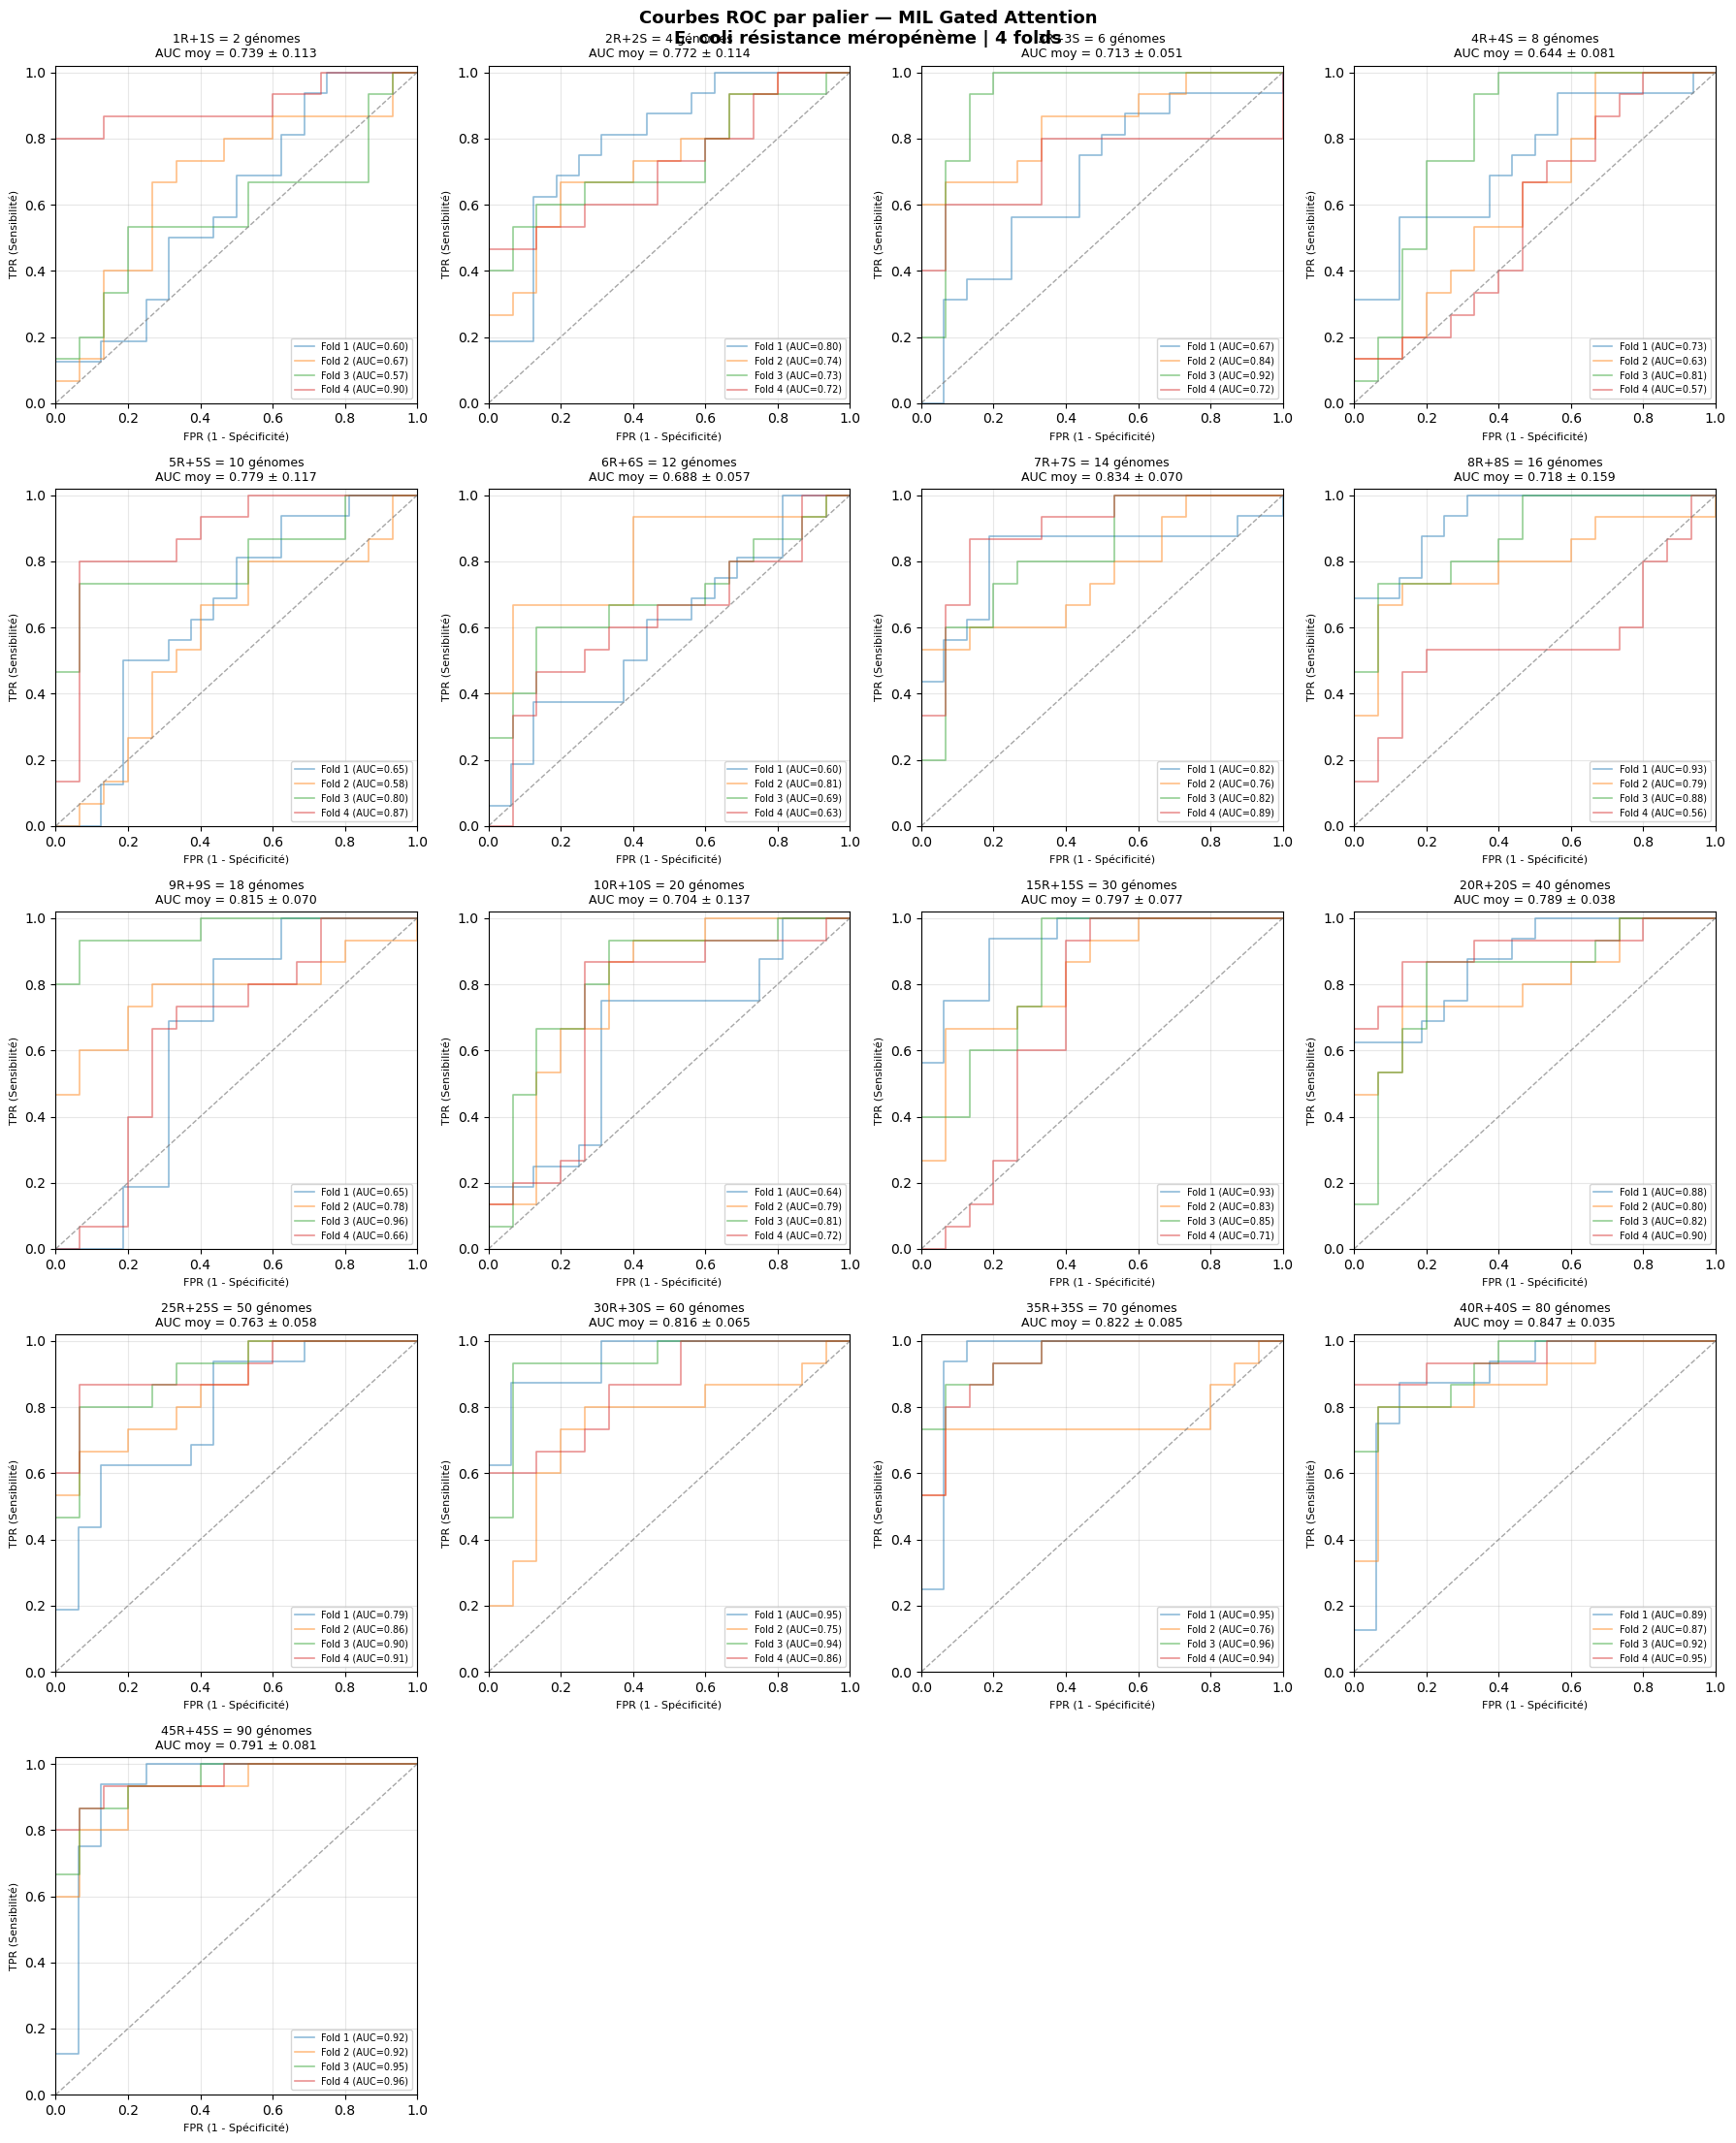

In [32]:
# Courbes ROC par palier

from sklearn.metrics import roc_curve, auc

n_paliers = len(lc_results)  
n_cols    = 4
n_rows    = (n_paliers + n_cols - 1) // n_cols  # calcul automatique du nb de lignes

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 4.5))
axes = axes.flatten()

colors = plt.cm.viridis(np.linspace(0, 1, len(lc_results)))

for ax_idx, r in enumerate(lc_results):
    ax = axes[ax_idx]

    n_per_class = r["n_per_class"]

    # Recalcule les courbes ROC pour chaque fold
    for fold_idx in range(N_FOLDS):

        seed_run = SEED + fold_idx * 100 + n_per_class
        set_seed(seed_run)

        # Reconstruit test set du fold
        te_R = fold_test_R[fold_idx]
        te_S = np.random.choice(susceptible_idx, size=len(te_R), replace=False)
        te_files = [matched[i] for i in np.concatenate([te_R, te_S])]
        te_ds    = GenomeMILDataset(te_files, id_to_y)
        te_loader = DataLoader(te_ds, batch_size=8, shuffle=False,
                               collate_fn=mil_collate)

        # Charge le meilleur modèle du palier
        model_roc = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
        #model_roc.load_state_dict(best_models[n_per_class])
        model_roc.load_state_dict(all_fold_models[n_per_class][fold_idx])
        model_roc.eval()

        test_y, test_prob = get_probs(model_roc, te_loader)

        if len(np.unique(test_y)) > 1:
            fpr, tpr, _ = roc_curve(test_y, test_prob)
            roc_auc     = auc(fpr, tpr)
            ax.plot(fpr, tpr, linewidth=1.2, alpha=0.5,
                    label=f"Fold {fold_idx+1} (AUC={roc_auc:.2f})")

    # Courbe moyenne (AUC moyen)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray",
            linewidth=1, alpha=0.7)

    ax.set_title(
        f"{n_per_class}R+{n_per_class}S = {2*n_per_class} génomes\n"
        f"AUC moy = {r['auc_mean']:.3f} ± {r['auc_std']:.3f}",
        fontsize=9
    )
    ax.set_xlabel("FPR (1 - Spécificité)", fontsize=8)
    ax.set_ylabel("TPR (Sensibilité)", fontsize=8)
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)

# Masque axes vides
for ax_idx in range(len(lc_results), len(axes)):
    axes[ax_idx].set_visible(False)

fig.suptitle(
    "Courbes ROC par palier — MIL Gated Attention\n"
    "E. coli résistance méropénème | 4 folds",
    fontsize=13, fontweight="bold"
)

plt.tight_layout()
#plt.savefig("roc_curves_MIL.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Figure sauvegardée → roc_curves_MIL.png")

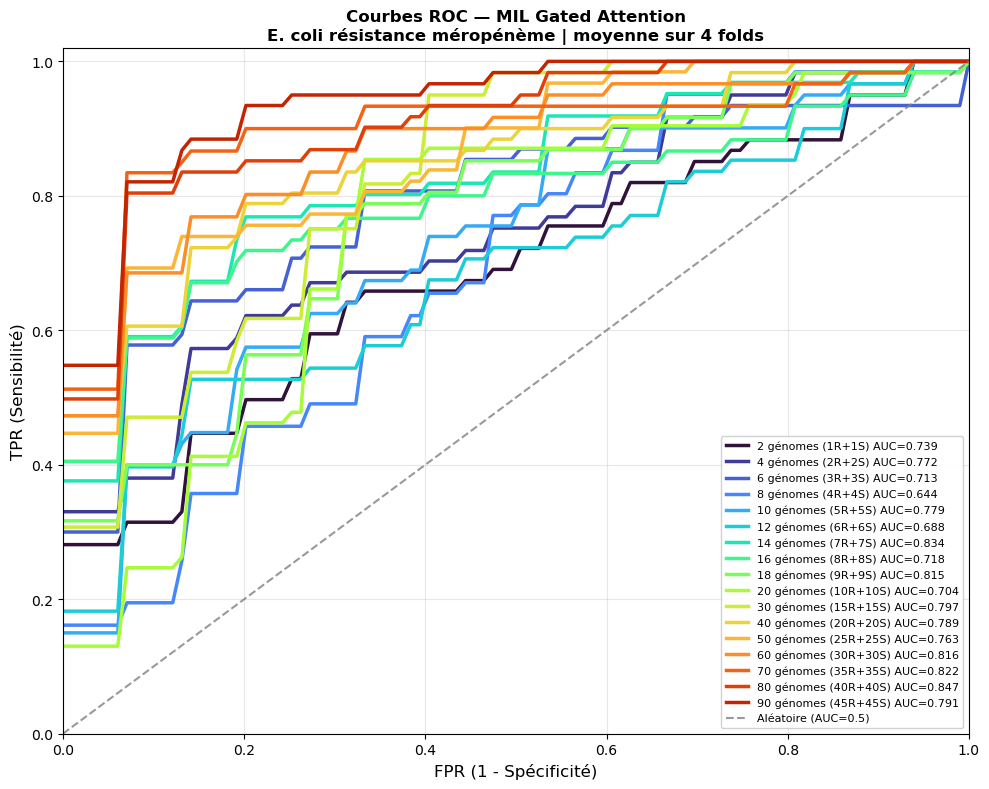

In [33]:
# Courbes ROC : tous paliers sur mm graphe
fig, ax = plt.subplots(figsize=(10, 8))

# Dégradé de couleurs
colors     = plt.cm.turbo(np.linspace(0.0, 0.9, len(lc_results)))  # tester (plasma, viridis, coolwarm, RdYlGn,turbo, rainbow)
linestyles = ["-"] * len(lc_results)
#linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":", "-"]

for i, (r, color, ls) in enumerate(zip(lc_results, colors, linestyles)):
    n_per_class = r["n_per_class"]
    all_fpr     = np.linspace(0, 1, 100)
    all_tpr     = []

    for fold_idx in range(N_FOLDS):
        seed_run = SEED + fold_idx * 100 + n_per_class
        set_seed(seed_run)
        te_R = fold_test_R[fold_idx]
        te_S = np.random.choice(susceptible_idx, size=len(te_R), replace=False)
        te_files  = [matched[i] for i in np.concatenate([te_R, te_S])]
        te_ds     = GenomeMILDataset(te_files, id_to_y)
        te_loader = DataLoader(te_ds, batch_size=8, shuffle=False,
                               collate_fn=mil_collate)
        model_roc = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
        model_roc.load_state_dict(all_fold_models[n_per_class][fold_idx])
        model_roc.eval()
        test_y, test_prob = get_probs(model_roc, te_loader)
        if len(np.unique(test_y)) > 1:
            fpr, tpr, _ = roc_curve(test_y, test_prob)
            tpr_interp  = np.interp(all_fpr, fpr, tpr)
            all_tpr.append(tpr_interp)

    if all_tpr:
        mean_tpr = np.mean(all_tpr, axis=0)
        mean_auc = r["auc_mean"]
        ax.plot(all_fpr, mean_tpr,
                linewidth=2.5,
                linestyle=ls,
                color=color,
                label=f"{2*n_per_class} génomes ({n_per_class}R+{n_per_class}S) "
                      f"AUC={mean_auc:.3f}")
        # ← fill_between supprimé !

# Diagonale aléatoire
ax.plot([0, 1], [0, 1], linestyle="--", color="gray",
        linewidth=1.5, alpha=0.8, label="Aléatoire (AUC=0.5)")
ax.set_xlabel("FPR (1 - Spécificité)", fontsize=12)
ax.set_ylabel("TPR (Sensibilité)", fontsize=12)
ax.set_title(
    "Courbes ROC — MIL Gated Attention\n"
    "E. coli résistance méropénème | moyenne sur 4 folds",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=8, loc="lower right",
          framealpha=0.9, ncol=1)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
#plt.savefig("roc_curves_combined.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
# Fonction load_labels + load_pt
PT_DIR   = "/shared/projects/pangaimix/dataset_61R_61S/embeddings"
GBK_DIR  = "/shared/projects/pangaimix/dataset_61R_61S/gbff"
RGI_DIR  = "/shared/projects/pangaimix/dataset_61R_61S/rgi"
LABELS_PATH = "matrice_listantibio_final.cleaned.list"
 
def load_labels(path):
    df = pd.read_csv(path, sep="\t", dtype=str)
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    df["Resistant"]   = df["Resistant"].astype(int)
    df["Susceptible"] = df["Susceptible"].astype(int)
    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"].astype(int)))
 
def load_pt(fp):
    obj = torch.load(fp)
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X   = obj["last_hidden_state"]
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)
    if X.ndim == 3:
        X = X.squeeze(0)
    if X.ndim != 2:
        raise ValueError(f"{fp}: shape inattendue {tuple(X.shape)}")
    return gid, X.float()
 
# Charge labels + fichiers
id_to_y   = load_labels(LABELS_PATH)
all_files = sorted(glob.glob(os.path.join(PT_DIR, "*.pt")))
matched   = [fp for fp in all_files if load_pt(fp)[0] in id_to_y]
resistant_files  = [fp for fp in matched if id_to_y[load_pt(fp)[0]] == 1]
susceptible_files= [fp for fp in matched if id_to_y[load_pt(fp)[0]] == 0]
 
print(f"Labels chargés")
print(f"Total .pt matchés  : {len(matched)}")
print(f"Résistants         : {len(resistant_files)}")
print(f"Sensibles          : {len(susceptible_files)}")

Labels chargés
Total .pt matchés  : 122
Résistants         : 61
Sensibles          : 61


In [35]:
# IDs dans tes .pt
pt_ids  = set(os.path.splitext(os.path.basename(f))[0]
              for f in glob.glob("/shared/projects/pangaimix/dataset_61R_61S/embeddings/*.pt"))

# IDs dans tes résultats RGI
rgi_ids = set(os.path.splitext(os.path.basename(f))[0]
              for f in glob.glob("/shared/projects/pangaimix/dataset_61R_61S/rgi/*.txt"))

# IDs dans tes .gbff
gbff_ids = set(os.path.splitext(os.path.basename(f))[0]
               for f in glob.glob("/shared/projects/pangaimix/dataset_61R_61S/gbff/*.gbff"))

print(f"IDs dans .pt   : {len(pt_ids)}")
print(f"IDs dans RGI   : {len(rgi_ids)}")
print(f"IDs dans .gbff : {len(gbff_ids)}")

IDs dans .pt   : 122
IDs dans RGI   : 122
IDs dans .gbff : 122


In [36]:
# Parser le .gbff pour extraire les CDS dans l'ordre
from Bio import SeqIO

def load_gbff_annotation(genome_id):
    gbff_file = os.path.join(GBK_DIR, f"{genome_id}.gbff")
    if not os.path.exists(gbff_file):
        print(f"Fichier non trouvé : {gbff_file}")
        return None
    rows = []
    for record in SeqIO.parse(gbff_file, "genbank"):
        for feature in record.features:
            if feature.type != "CDS":
                continue
            rows.append({
                "contig":    record.id,
                "start":     int(feature.location.start),
                "end":       int(feature.location.end),
                "strand":    int(feature.location.strand),
                "locus_tag": feature.qualifiers.get("locus_tag", [""])[0],
                "gene":      feature.qualifiers.get("gene",      [""])[0],
                "product":   feature.qualifiers.get("product",   ["unknown"])[0],
            })
    if not rows:
        print(f"Aucun CDS trouvé")
        return None
    df = pd.DataFrame(rows).reset_index()
    return df.rename(columns={"index": "protein_index"})
 
# Test sur le premier génome disponible
sample_gid = load_pt(all_files[0])[0]
ann_test   = load_gbff_annotation(sample_gid)
 
if ann_test is not None:
    print(f".gbff chargé pour : {sample_gid}")
    print(f"   Nb CDS : {len(ann_test)}")
    print(ann_test[["protein_index","gene","product","start","end"]].head(10))
else:
    print("Problème — vérifie GBK_DIR et le nom des fichiers")

.gbff chargé pour : 1328437.3
   Nb CDS : 5182
   protein_index    gene                                            product  \
0              0    dkgB                       Methylglyoxal reductase DkgB   
1              1    crgA            HTH-type transcriptional regulator CrgA   
2              2                                       hypothetical protein   
3              3    ycgJ                    putative methyltransferase YcgJ   
4              4    mltD     Membrane-bound lytic murein transglycosylase D   
5              5    gloB              Hydroxyacylglutathione hydrolase GloB   
6              6  bioC_1  Malonyl-[acyl-carrier protein] O-methyltransfe...   
7              7    rnhA                                    Ribonuclease HI   
8              8    dnaQ                 DNA polymerase III subunit epsilon   
9              9                                       hypothetical protein   

   start    end  
0   1201   2005  
1   2001   2916  
2   3177   3957  
3   4033   

In [37]:
# Récupère tous les Drug Class uniques dans tous les fichiers RGI
all_drug_classes = set()

for fp in matched[:50]:   # teste sur 50 génomes
    gid = load_pt(fp)[0]
    rgi_file = os.path.join(RGI_DIR, f"{gid}.txt")
    if not os.path.exists(rgi_file):
        continue
    df = pd.read_csv(rgi_file, sep="\t")
    df = df[df["Cut_Off"].isin(["Perfect", "Strict"])]
    for dc in df["Drug Class"].dropna().unique():
        # Sépare les classes combinées par ";"
        for c in dc.split(";"):
            all_drug_classes.add(c.strip().lower())

# Affiche toutes les classes
print(f"Total classes uniques : {len(all_drug_classes)}\n")
print("Toutes les Drug Class :")
for dc in sorted(all_drug_classes):
    print(f"  → {dc}")

# Filtre celles qui contiennent "penem"
print(f"\nClasses contenant 'penem' :")
for dc in sorted(all_drug_classes):
    if "penem" in dc:
        print(f" {dc}")

Total classes uniques : 26

Toutes les Drug Class :
  → aminocoumarin antibiotic
  → aminoglycoside antibiotic
  → carbapenem
  → cephalosporin
  → diaminopyrimidine antibiotic
  → disinfecting agents and antiseptics
  → elfamycin antibiotic
  → fluoroquinolone antibiotic
  → glycopeptide antibiotic
  → glycylcycline
  → lincosamide antibiotic
  → macrolide antibiotic
  → monobactam
  → nitrofuran antibiotic
  → nitroimidazole antibiotic
  → nucleoside antibiotic
  → penicillin beta-lactam
  → peptide antibiotic
  → phenicol antibiotic
  → phosphonic acid antibiotic
  → rifamycin antibiotic
  → streptogramin a antibiotic
  → streptogramin antibiotic
  → streptogramin b antibiotic
  → sulfonamide antibiotic
  → tetracycline antibiotic

Classes contenant 'penem' :
 carbapenem


In [38]:
# Charge et affiche le fichier EggNOG
import pandas as pd

eggnog_file = "/shared/projects/pangaimix/pangenome_emapper_out.emapper.annotations"

df_egg = pd.read_csv(eggnog_file, sep="\t", comment="#", header=None,
                     names=["query", "seed_ortholog", "evalue", "score",
                             "eggNOG_OGs", "max_annot_lvl", "COG_category",
                             "Description", "Preferred_name", "GOs",
                             "EC", "KEGG_ko", "KEGG_Pathway", "KEGG_Module",
                             "KEGG_Reaction", "KEGG_rclass", "BRITE", "KEGG_TC",
                             "CAZy", "BiGG_Reaction", "PFAMs"])

print(f"Nb lignes : {len(df_egg)}")
print(f"\nColonnes : {df_egg.columns.tolist()}")
print(f"\nExemples query :")
print(df_egg["query"].head(10).tolist())
print(f"\nExemple ligne complète :")
print(df_egg.head(2).to_string())

Nb lignes : 39024

Colonnes : ['query', 'seed_ortholog', 'evalue', 'score', 'eggNOG_OGs', 'max_annot_lvl', 'COG_category', 'Description', 'Preferred_name', 'GOs', 'EC', 'KEGG_ko', 'KEGG_Pathway', 'KEGG_Module', 'KEGG_Reaction', 'KEGG_rclass', 'BRITE', 'KEGG_TC', 'CAZy', 'BiGG_Reaction', 'PFAMs']

Exemples query :
['KLOOMICH_02583', 'ANCNFLFM_03327', 'CHDOAAOC_01392', 'BDPGOHIM_04143', 'GCPLADEG_02534', 'GCPLADEG_02536', 'GCPLADEG_04164', 'GCPLADEG_04171', 'GCPLADEG_04172', 'GCPLADEG_04173']

Exemple ligne complète :
            query                  seed_ortholog        evalue  score                                                                                                            eggNOG_OGs              max_annot_lvl COG_category                                 Description Preferred_name GOs EC KEGG_ko KEGG_Pathway KEGG_Module KEGG_Reaction KEGG_rclass BRITE KEGG_TC CAZy BiGG_Reaction   PFAMs
0  KLOOMICH_02583  1336249.JADW01000010_gene1210  2.420000e-44  152.0  COG1309@1|roo

In [39]:
# Charge gene_families.tsv
GENE_FAMILIES = "/shared/projects/pangaimix/gene_families.tsv"
EGGNOG_FILE   = "/shared/projects/pangaimix/pangenome_emapper_out.emapper.annotations"

print("Chargement gene_families...")
df_fam = pd.read_csv(GENE_FAMILIES, sep="\t", header=None,
                     usecols=[0, 1],
                     names=["family", "member"])

print(f"  → {len(df_fam)} membres")
print(f"  → {df_fam['family'].nunique()} familles")
print(f"  Exemple : {df_fam.head(3).to_string()}")

# Charge EggNOG
print("\nChargement EggNOG...")
df_egg = pd.read_csv(EGGNOG_FILE, sep="\t", comment="#", header=None,
                     names=["query", "seed_ortholog", "evalue", "score",
                             "eggNOG_OGs", "max_annot_lvl", "COG_category",
                             "Description", "Preferred_name", "GOs",
                             "EC", "KEGG_ko", "KEGG_Pathway", "KEGG_Module",
                             "KEGG_Reaction", "KEGG_rclass", "BRITE", "KEGG_TC",
                             "CAZy", "BiGG_Reaction", "PFAMs"])
df_egg = df_egg.replace("-", None)
print(f"  → {len(df_egg)} annotations")

# Jointure famille → EggNOG
# Dict : family_id → annotation EggNOG
eggnog_by_family = {}
for _, row in df_egg.iterrows():
    eggnog_by_family[row["query"]] = {
        "description":    row["Description"],
        "preferred_name": row["Preferred_name"],
        "cog_category":   row["COG_category"],
        "kegg_pathway":   row["KEGG_Pathway"],
        "kegg_ko":        row["KEGG_ko"],
    }
print(f"  → {len(eggnog_by_family)} familles annotées")

# Dict : membre → famille
member_to_family = dict(zip(df_fam["member"], df_fam["family"]))
print(f"\nMember to family : {len(member_to_family)} membres")

# Lookup final : locus_tag → EggNOG
def get_eggnog_for_locus(locus_tag):
    """
    locus_tag → famille PPanGGOLiN → annotation EggNOG
    """
    family = member_to_family.get(locus_tag, None)
    if family is None:
        return None
    return eggnog_by_family.get(family, None)

# Test
test_locus = "EHGLCAJA_00079"
result = get_eggnog_for_locus(test_locus)
print(f"\nTest : {test_locus}")
print(f"  → famille : {member_to_family.get(test_locus, 'NON TROUVÉ')}")
print(f"  → EggNOG  : {result}")

Chargement gene_families...
  → 5100114 membres
  → 49243 familles
  Exemple :            family          member
0  MNPEEKGE_04727  AAFMBIGD_03840
1  MNPEEKGE_04727  AAFMBIGD_04107
2  MNPEEKGE_04727  AAFMBIGD_04357

Chargement EggNOG...
  → 39024 annotations
  → 39024 familles annotées

Member to family : 5100114 membres

Test : EHGLCAJA_00079
  → famille : MPIKEPCM_03994
  → EggNOG  : {'description': 'uxaCA, sdaCB and yjiY. H-NS repression of the bgl operon, leading to the ability to metabolize some beta-glucosides. It also directly activates the bgl operon. Activation is H-NS and BglJ-RcsB independent', 'preferred_name': 'leuO', 'cog_category': 'K', 'kegg_pathway': None, 'kegg_ko': 'ko:K05798'}


In [41]:
# top protéines annotées + RGI

N_BEST = 40   

assert N_BEST in best_models, \
    f"Palier {N_BEST} non disponible. Paliers dispo : {list(best_models.keys())}"

model_best = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
model_best.load_state_dict(best_models[N_BEST])
model_best.eval()

r_info = next(x for x in lc_results if x["n_per_class"] == N_BEST)
print(f"Modèle chargé : palier {N_BEST}R+{N_BEST}S = {2*N_BEST} génomes")
print(f"   AUC  : {r_info['auc_mean']:.3f} ± {r_info['auc_std']:.3f}")
print(f"   F1   : {r_info['f1_mean']:.3f} ± {r_info['f1_std']:.3f}")
print(f"   AUC par fold : {[round(a,3) for a in r_info['fold_aucs']]}")
print(f"   Meilleur fold : {r_info['best_fold']}\n")

# Full eval loader
full_dataset     = GenomeMILDataset(matched, id_to_y)
full_eval_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=mil_collate)

# Eggnig via Ppanggolin gene_families

GENE_FAMILIES = "/shared/projects/pangaimix/gene_families.tsv"
EGGNOG_FILE   = "/shared/projects/pangaimix/pangenome_emapper_out.emapper.annotations"

print("Chargement gene_families...")
df_fam = pd.read_csv(GENE_FAMILIES, sep="\t", header=None,
                     usecols=[0, 1],
                     names=["family", "member"])
member_to_family = dict(zip(df_fam["member"], df_fam["family"]))
print(f"  → {len(member_to_family)} membres")

print("Chargement EggNOG...")
df_egg = pd.read_csv(EGGNOG_FILE, sep="\t", comment="#", header=None,
                     names=["query", "seed_ortholog", "evalue", "score",
                             "eggNOG_OGs", "max_annot_lvl", "COG_category",
                             "Description", "Preferred_name", "GOs",
                             "EC", "KEGG_ko", "KEGG_Pathway", "KEGG_Module",
                             "KEGG_Reaction", "KEGG_rclass", "BRITE", "KEGG_TC",
                             "CAZy", "BiGG_Reaction", "PFAMs"])
df_egg = df_egg.replace("-", None)

eggnog_by_family = {}
for _, row in df_egg.iterrows():
    eggnog_by_family[row["query"]] = {
        "description":    row["Description"],
        "preferred_name": row["Preferred_name"],
        "cog_category":   row["COG_category"],
        "kegg_pathway":   row["KEGG_Pathway"],
        "kegg_ko":        row["KEGG_ko"],
    }
print(f"  → {len(eggnog_by_family)} familles annotées")

def get_eggnog_for_locus(locus_tag):
    family = member_to_family.get(locus_tag, None)
    if family is None:
        return None
    return eggnog_by_family.get(family, None)


# RGI lookup par locus_tag

def load_rgi_lookup(genome_id):
    """
    Retourne dict : locus_tag → {pct_identity, aro, drug_class, cut_off}
    Jointure via ORF_ID qui contient le locus_tag Prokka
    ex : ORF_ID = "EHGLCAJA_00079 HTH-type..." → locus_tag = "EHGLCAJA_00079"
    """
    rgi_file = os.path.join(RGI_DIR, f"{genome_id}.txt")
    if not os.path.exists(rgi_file):
        return {}

    df = pd.read_csv(rgi_file, sep="\t")
    df = df[df["Cut_Off"].isin(["Perfect", "Strict"])]
    
    lookup = {}
    for _, row in df.iterrows():
        orf_id    = str(row["ORF_ID"])
        locus_tag = orf_id.split(" ")[0]
        lookup[locus_tag] = {
            "pct_identity": float(row["Best_Identities"]) \
                            if pd.notna(row["Best_Identities"]) else None,
            "drug_class":   str(row["Drug Class"]),
            "aro":          str(row["Best_Hit_ARO"]),
            "cut_off":      str(row["Cut_Off"]),
        }
    return lookup

# Fonction principale

def get_top_attention_with_annotation(model, loader, gbk_dir=GBK_DIR, top_k=50):
    model.eval()
    results = []
    with torch.no_grad():
        for Xpad, mask, y, gids in loader:
            Xpad, mask    = Xpad.to(device), mask.to(device)
            logits, alpha = model(Xpad, mask)
            probs         = torch.sigmoid(logits).cpu().numpy()

            for i, gid in enumerate(gids):
                n_prot  = int(mask[i].sum().item())
                attn    = alpha[i, :n_prot].cpu().numpy()
                top_idx = np.argsort(attn)[::-1][:top_k]

                entropy     = float(-np.sum(attn * np.log(attn + 1e-12)))
                max_entropy = float(np.log(n_prot))

                ann        = load_gbff_annotation(gid)
                rgi_lookup = load_rgi_lookup(gid)

                top_proteins = []
                for rank, idx in enumerate(top_idx, 1):
                    entry = {
                        "rank":             rank,
                        "protein_index":    int(idx),
                        "attention_weight": float(attn[idx]),
                        "attention_pct":    float(100 * attn[idx] / attn.sum()),
                    }

                    # Annotation gbff
                    if ann is not None and idx < len(ann):
                        row       = ann.iloc[idx]
                        locus_tag = row.get("locus_tag", None) or "—"
                        entry["gene"]      = row.get("gene",    None) or "—"
                        entry["product"]   = row.get("product", None) or "—"
                        entry["locus_tag"] = locus_tag
                    else:
                        locus_tag          = "—"
                        entry["gene"]      = "?"
                        entry["product"]   = "?"
                        entry["locus_tag"] = "?"

                    # Jointure RGI par locus_tag
                    rgi_info = rgi_lookup.get(locus_tag, None)
                    entry["rgi_pct_identity"] = rgi_info["pct_identity"] \
                                                if rgi_info else None
                    entry["rgi_aro"]          = rgi_info["aro"] \
                                                if rgi_info else "—"
                    entry["rgi_drug_class"]   = rgi_info["drug_class"] \
                                                if rgi_info else "—"
                    entry["rgi_cut_off"]      = rgi_info["cut_off"] \
                                                if rgi_info else "—"

                    # Jointure EggNOG via PPanGGOLiN
                    egg_info = get_eggnog_for_locus(locus_tag)
                    entry["eggnog_description"]    = egg_info["description"] \
                                                     if egg_info else "—"
                    entry["eggnog_preferred_name"] = egg_info["preferred_name"] \
                                                     if egg_info else "—"
                    entry["eggnog_cog"]            = egg_info["cog_category"] \
                                                     if egg_info else "—"
                    entry["eggnog_kegg"]           = egg_info["kegg_pathway"] \
                                                     if egg_info else "—"

                    top_proteins.append(entry)

                results.append({
                    "genome_id":        gid,
                    "true_label":       int(y[i].item()),
                    "predicted_prob":   float(probs[i]),
                    "predicted_label":  int(probs[i] >= 0.5),
                    "correct":          int(y[i].item()) == int(probs[i] >= 0.5),
                    "n_proteins":       n_prot,
                    "attn_entropy_pct": float(entropy / max_entropy) \
                                        if max_entropy > 0 else 1.0,
                    "top_proteins":     top_proteins,
                })
    return results

# Affichage

def affiche_genomes(genome_list, label_str, n_display=5,
                    pyseer_lookup=None, significant_tags=None):
    """
    pyseer_lookup   : dict locus_tag → {"lrt-pvalue": ..., "beta": ...}
                      (construit après avoir chargé pyseer_lmm.assoc)
    significant_tags: set des locus_tags significatifs (hits Bonferroni)
    """
    if pyseer_lookup    is None: pyseer_lookup    = {}
    if significant_tags is None: significant_tags = set()

    correct = sum(1 for r in genome_list if r["correct"])
    print(f"\n{'#'*140}")
    print(f"  {label_str} ({len(genome_list)} génomes total) "
          f"— Prédictions correctes : {correct}/{len(genome_list)} "
          f"({correct/len(genome_list):.1%})")
    print(f"  Affichage des {min(n_display, len(genome_list))} premiers")
    print(f"{'#'*140}")

    for r in genome_list[:n_display]:
        icon = "CORRECT" if r["correct"] else "NOT CORRECT"
        print(f"\n{'='*140}")
        print(f"{icon}  Genome : {r['genome_id']}  |  "
              f"P(resistant)={r['predicted_prob']:.3f}  |  "
              f"{r['n_proteins']} protéines  |  "
              f"Entropie : {r['attn_entropy_pct']:.1%}")
        print(f"{'='*140}")
        print(
            f"{'Rang':>4} | {'Idx':>6} | {'Poids':>12} | {'%attn':>6} | "
            f"{'Gène':>10} | {'Produit':<20} | "
            f"{'RGI%':>6} | {'ARO':<15} | {'Drug Class':<15} | "
            f"{'EggNOG name':<15} | {'COG':>3} | {'Description':<25} | "
            f"{'p-value':>12} | {'Signif':>6}"
            #f"{'Locus tag':<20} | {'p-value':>12} | {'Signif':>6}"
        )
        print("-" * 140)

        for p in r["top_proteins"]:
            rgi_pct   = f"{p['rgi_pct_identity']:.1f}%" \
                        if p["rgi_pct_identity"] is not None else "—"
            locus_tag = str(p.get("locus_tag", "—"))

            pyseer_info = pyseer_lookup.get(locus_tag, None)
            pval_str    = f"{pyseer_info['lrt-pvalue']:.2E}" \
                          if pyseer_info else "—"
            signif_str  = "OUI" if locus_tag in significant_tags else "non"

            print(
                f"{p['rank']:>4} | "
                f"{p['protein_index']:>6} | "
                f"{p['attention_weight']:>12.8f} | "
                f"{p['attention_pct']:>5.2f}% | "
                f"{str(p['gene'])[:10]:>10} | "
                f"{str(p['product'])[:20]:<20} | "
                f"{rgi_pct:>6} | "
                f"{str(p['rgi_aro'])[:15]:<15} | "
                f"{str(p['rgi_drug_class'])[:15]:<15} | "
                f"{str(p['eggnog_preferred_name'])[:15]:<15} | "
                f"{str(p['eggnog_cog'])[:3]:>3} | "
                f"{str(p['eggnog_description'])[:25]:<25} | "
                #f"{locus_tag:<20} | "
                f"{pval_str:>12} | "
                f"{signif_str:>6}"
            )

top_attn_ann  = get_top_attention_with_annotation(
    model_best, full_eval_loader, top_k=50)
resistant_ann = [r for r in top_attn_ann if r["true_label"] == 1]
sensible_ann  = [r for r in top_attn_ann if r["true_label"] == 0]

# Pyseer
_pyseer_all = pd.read_csv(
    "/shared/projects/pangaimix/pyseer_122_results/pyseer_lmm.assoc", sep="\t")
_pyseer_all["locus_tag"] = _pyseer_all["variant"].str.rstrip("_")
pyseer_lookup = {
    row["locus_tag"]: {"lrt-pvalue": row["lrt-pvalue"], "beta": row["beta"]}
    for _, row in _pyseer_all.iterrows()
}
_pyseer_hits = pd.read_csv(
    "/shared/projects/pangaimix/pyseer_122_results/significant_hits.txt", sep="\t")
significant_tags = set(_pyseer_hits["variant"].str.rstrip("_").tolist())
print(f"Lookup pyseer chargé : {len(pyseer_lookup)} variants")
print(f"Hits significatifs   : {len(significant_tags)}")

affiche_genomes(resistant_ann, "GÉNOMES RÉSISTANTS", n_display=5,
                pyseer_lookup=pyseer_lookup, significant_tags=significant_tags)
affiche_genomes(sensible_ann,  "GÉNOMES SENSIBLES",  n_display=5,
                pyseer_lookup=pyseer_lookup, significant_tags=significant_tags)
# Export CSV

def build_rows(genome_list):
    rows = []
    for r in genome_list:
        for p in r["top_proteins"]:
            rows.append({
                "genome_id":             r["genome_id"],
                "true_label":            r["true_label"],
                "predicted_prob":        round(r["predicted_prob"], 4),
                "correct":               r["correct"],
                "n_proteins":            r["n_proteins"],
                "attn_entropy_pct":      round(r["attn_entropy_pct"], 4),
                "rank":                  p["rank"],
                "protein_index":         p["protein_index"],
                "attention_weight":      p["attention_weight"],
                "attention_pct":         p["attention_pct"],
                "gene":                  p["gene"],
                "product":               p["product"],
                #"locus_tag":             p["locus_tag"],
                "rgi_pct_identity":      p["rgi_pct_identity"],
                "rgi_aro":               p["rgi_aro"],
                "rgi_drug_class":        p["rgi_drug_class"],
                "rgi_cut_off":           p["rgi_cut_off"],
                "eggnog_description":    p["eggnog_description"],
                "eggnog_preferred_name": p["eggnog_preferred_name"],
                "eggnog_cog":            p["eggnog_cog"],
                "eggnog_kegg":           p["eggnog_kegg"],
            })
    return rows

# Export CSV résistants + sensibles
#df_R = pd.DataFrame(build_rows(resistant_ann))
#df_R.to_csv(f"top_attention_{N_BEST}R_resistants.csv", index=False)
#print(f"\nExport résistants → top_attention_{N_BEST}R_resistants.csv "
      #f"({len(resistant_ann)} génomes | {len(df_R)} lignes)")

#df_S = pd.DataFrame(build_rows(sensible_ann))
#df_S.to_csv(f"top_attention_{N_BEST}R_sensibles.csv", index=False)
#print(f"Export sensibles  → top_attention_{N_BEST}R_sensibles.csv "
      #f"({len(sensible_ann)} génomes | {len(df_S)} lignes)")

Modèle chargé : palier 40R+40S = 80 génomes
   AUC  : 0.847 ± 0.035
   F1   : 0.751 ± 0.073
   AUC par fold : [np.float64(0.863), np.float64(0.8), np.float64(0.831), np.float64(0.893)]
   Meilleur fold : 4

Chargement gene_families...
  → 5100114 membres
Chargement EggNOG...
  → 39024 familles annotées
Lookup pyseer chargé : 10173 variants
Hits significatifs   : 29

############################################################################################################################################
  GÉNOMES RÉSISTANTS (61 génomes total) — Prédictions correctes : 55/61 (90.2%)
  Affichage des 5 premiers
############################################################################################################################################

CORRECT  Genome : 1328437.3  |  P(resistant)=0.999  |  5202 protéines  |  Entropie : 35.1%
Rang |    Idx |        Poids |  %attn |       Gène | Produit              |   RGI% | ARO             | Drug Class      | EggNOG name     | COG | Descr

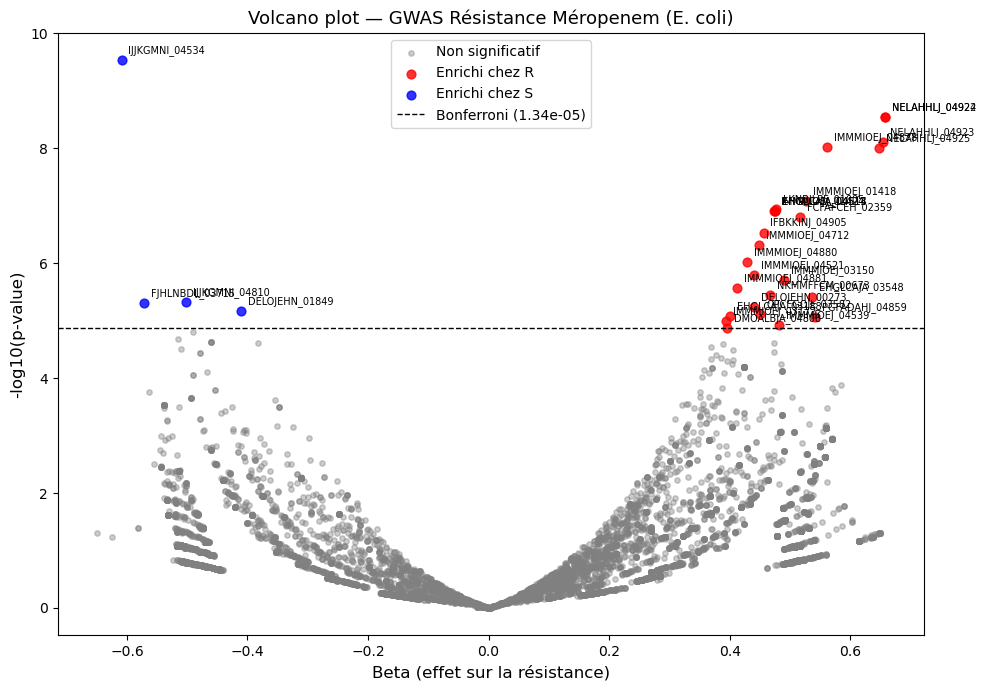

volcano_plot_pyseer.png sauvegardé


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Charger les résultats
df = pd.read_csv("/shared/projects/pangaimix/pyseer_122_results/pyseer_lmm.assoc", sep="\t")
df["locus_tag"] = df["variant"].str.rstrip("_")

# Calculer -log10(p-value)
df["-log10p"] = -np.log10(df["lrt-pvalue"].astype(float))

# Seuil Bonferroni
threshold = 1.34e-05
log_threshold = -np.log10(threshold)

# Couleurs : significatif ou non
df["color"] = "grey"
df.loc[(df["lrt-pvalue"] < threshold) & (df["beta"] > 0), "color"] = "red"    # R enrichi
df.loc[(df["lrt-pvalue"] < threshold) & (df["beta"] < 0), "color"] = "blue"   # S enrichi

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    df[df["color"] == "grey"]["beta"],
    df[df["color"] == "grey"]["-log10p"],
    c="grey", alpha=0.4, s=15, label="Non significatif"
)
ax.scatter(
    df[df["color"] == "red"]["beta"],
    df[df["color"] == "red"]["-log10p"],
    c="red", alpha=0.8, s=40, label="Enrichi chez R"
)
ax.scatter(
    df[df["color"] == "blue"]["beta"],
    df[df["color"] == "blue"]["-log10p"],
    c="blue", alpha=0.8, s=40, label="Enrichi chez S"
)

# Ligne seuil Bonferroni
ax.axhline(y=log_threshold, color="black", linestyle="--",
           linewidth=1, label=f"Bonferroni ({threshold:.2e})")

# Annoter les hits significatifs
sig = df[df["lrt-pvalue"] < threshold]
for _, row in sig.iterrows():
    ax.annotate(
        row["locus_tag"],
        xy=(row["beta"], row["-log10p"]),
        xytext=(5, 5), textcoords="offset points",
        fontsize=7, color="black"
    )

ax.set_xlabel("Beta (effet sur la résistance)", fontsize=12)
ax.set_ylabel("-log10(p-value)", fontsize=12)
ax.set_title("Volcano plot — GWAS Résistance Méropenem (E. coli)", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("volcano_plot_pyseer.png", dpi=300)
plt.show()
print("volcano_plot_pyseer.png sauvegardé")